# Multidimensional poverty in Ethiopia (DHS 2019)

Beyond income poverty, which bundles of deprivation cluster together in Ethiopia, and how does that vary by region?


## The question

Income-line poverty miscounts in low-resource settings — informal subsistence is undercounted, and non-monetary deprivations (clean water, electricity, school attendance) don't appear in an income line at all. We reproduce the **OPHI Global Multidimensional Poverty Index** for Ethiopia from the DHS 2019 microdata, with correct survey design (clusters + strata + sampling weights), decompose MPI by region and deprivation dimension, and overlay a **descriptive** ML feature-importance pass (RandomForest / XGBoost + SHAP) to surface which household characteristics most associate with MPI status.

This is a **methodological reproduction with extension**, not a targeting tool (no program design / ethics review), not a cross-country comparison (different exercise), and not a causal claim about what drives poverty (the ML step is descriptive feature importance).


## Data

| Source | Granularity | Time | Notes |
|---|---|---|---|
| [DHS Ethiopia](https://dhsprogram.com/data/dataset/Ethiopia_Standard-DHS_2019.cfm) | Household + member records with clusters, strata, weights | 2019 | Registered-access microdata; **not committed** (license forbids redistribution). |
| [OPHI Global MPI methodology](https://ophi.org.uk/multidimensional-poverty-index/) | 10 indicators across 3 dimensions, with weights | — | Faithfully reproduced; deviations documented inline. |
| [GADM 4.1](https://gadm.org/) | Ethiopia admin-1 region polygons | Current | Crosswalked to DHS region codes in `data.py`. |

We load just the columns we need — the real recodes are very wide (HR ~1,400 cols, PR ~3,000) — and join the births recode (BR) for the child-mortality indicator. The household feature set for the ML pass is loaded into the same HR slice (union of indicator + feature columns).


In [1]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning, module="pandas")

import numpy as np
import pandas as pd

from ethiopia_mpi import mpi, ml
from ethiopia_mpi.data import load_dhs_recode, load_gadm_admin1, region_crosswalk
from ethiopia_mpi.diagnostics import missingness_summary
from ethiopia_mpi import viz

# HR columns: union of those needed by the MPI engine and the ML feature set.
HR_COLS = sorted(set(mpi.HR_COLS) | {"hv009", "hv040", "hv246", "hv270", "hv271"})
hr = load_dhs_recode("HR", columns=HR_COLS)
pr = load_dhs_recode("PR", columns=mpi.PR_COLS)
br = load_dhs_recode("BR", columns=mpi.BR_COLS)

print(f"HR: {hr.shape[0]:,} households x {hr.shape[1]} cols")
print(f"PR: {pr.shape[0]:,} persons x {pr.shape[1]} cols")
print(f"BR: {br.shape[0]:,} births x {br.shape[1]} cols")


HR: 8,663 households x 29 cols
PR: 40,659 persons x 9 cols
BR: 23,007 births x 3 cols


## Cleaning & structuring: the 10 OPHI indicators

The OPHI Global MPI is built from 10 deprivation indicators across three equally-weighted dimensions (health / education / living standards). We construct them per household from HR (living standards + design columns), PR (nutrition / schooling / school attendance, aggregated from members), and BR (child mortality).

In [2]:
indicators = mpi.build_indicators(hr, pr, br)
print(f"Indicators built for {len(indicators):,} households "
      f"({len(mpi.INDICATORS)} indicators each)")
indicators[mpi.INDICATORS].head()


Indicators built for 8,663 households (10 indicators each)


nutrition  child_mortality  years_schooling  school_attendance  \
hv001 hv002                                                                   
1     8            0.0              0.0              0.0                0.0   
      14           1.0              0.0              0.0                0.0   
      21           0.0              0.0              0.0                0.0   
      28           NaN              0.0              1.0                0.0   
      34           NaN              0.0              0.0                0.0   

             cooking_fuel  sanitation  drinking_water  electricity  housing  \
hv001 hv002                                                                   
1     8               0.0         0.0             0.0          0.0      0.0   
      14              0.0         0.0             0.0          0.0      0.0   
      21              0.0         0.0             0.0          0.0      0.0   
      28              0.0         0.0             0.0          0.0      0.0   
      34              0.0         0.0             0.0          0.0      0.0   

             assets  
hv001 hv002          
1     8         0.0  
      14        0.0  
      21        0.0  
      28        0.0  
      34        0.0

### Decision 1 — Treatment of missing indicator items

**Problem.** Each household needs all 10 OPHI indicators to get a deprivation score. Some indicators are missing for some households — a missing toilet-type code, an under-5 child with no anthropometry. If we silently sum the observed weights, an incomplete household gets an artificially *low* score and is pushed out of poverty by missing data, not by being non-poor. If we drop every incomplete household we lose sample, and the loss may not be random across regions. The choice changes both the headcount and who is in the denominator.

**Diagnostic.** How many households are incomplete, which indicators drive it, and is the missingness concentrated by region?

In [3]:
# How missing is each indicator, and how many households are incomplete?
ind_missing = missingness_summary(indicators[mpi.INDICATORS])
display(ind_missing)

scored_drop = mpi.deprivation_score(indicators, missing_policy="drop")
n_total = len(scored_drop)
n_incomplete = int((scored_drop["n_missing_ind"] > 0).sum())
print(f"{n_incomplete:,} / {n_total:,} households missing >= 1 indicator "
      f"({n_incomplete / n_total:.1%})")

# Is the loss random across regions, or would dropping bias the regional map?
loss_by_region = (
    scored_drop.assign(incomplete=scored_drop["n_missing_ind"] > 0)
    .groupby("hv024")["incomplete"].mean().mul(100).round(1)
)
display(loss_by_region.rename("pct_dropped"))


,column,n_missing,pct_missing
0,nutrition,3133,36.17
2,years_schooling,1,0.01
1,child_mortality,0,0.00
3,school_attendance,0,0.00
4,cooking_fuel,0,0.00
5,sanitation,0,0.00
6,drinking_water,0,0.00
7,electricity,0,0.00
8,housing,0,0.00
9,assets,0,0.00


3,134 / 8,663 households missing >= 1 indicator (36.2%)


hv024
1     33.5
2     24.4
3     38.5
4     34.3
5     29.2
6     33.5
7     33.9
8     37.5
9     40.1
10    50.0
11    42.5
Name: pct_dropped, dtype: float64

**Options considered.**

- (a) **Drop incomplete households** — OPHI's standard complete-case treatment. Unbiased *if* missingness is unrelated to poverty; costs sample.
- (b) **Impute the missing item** — keeps every household, but injects a modelling assumption into a measurement exercise and can manufacture deprivation status the data never observed.
- (c) **Available-case / partial MPI** — renormalise OPHI weights over the observed indicators. Keeps every household, but a household scored on 8 indicators is not strictly comparable to one scored on 10.

**Decision.** Use **(a) drop incomplete households** for the headline MPI. The diagnostic above shows this is *not* a small concession — **~36% of households are dropped**, driven almost entirely by nutrition (households with under-5 children or eligible women but no valid anthropometric measurements), and the drop rate ranges roughly **24%–50%** across regions. We still take the OPHI standard because the entire point of using OPHI's methodology is cross-country comparability, and OPHI's published Ethiopia figures use complete-case scoring. But the size of the loss makes the available-case robustness check load-bearing rather than ceremonial — see Sensitivity.

**Sensitivity.** Re-run with `missing_policy="available-case"` in `03_robustness.ipynb` — the available-case policy renormalises OPHI weights over observed indicators and keeps all 8,663 households in scope. The check we care about is whether the **regional MPI ranking** is stable across the two policies (level shifts are expected; rank inversions would be a problem).


## MPI computation

We now combine the indicators into the weighted deprivation score, apply the OPHI poverty cutoff k, and estimate the headline H / A / MPI nationally and per region — all through the DHS survey design.

### Decision 2 — Multidimensional poverty cutoff k

**Problem.** A household is "multidimensionally poor" when its weighted deprivation score reaches a cutoff k. k is a value judgement, not an estimate: a low k counts the mildly deprived as poor (high headcount), a high k counts only the severely deprived. The headline headcount H — and therefore MPI — moves materially with k, so the choice must be stated and defended, not buried.

**Diagnostic.** How sensitive is the national headcount to k across the plausible range?

In [4]:
rows = []
for k in (0.20, 1/3, 0.50):
    hh_k = mpi.build_household_mpi(hr, pr, br, k=k)
    nat = mpi.headcount_intensity_mpi(hh_k).iloc[0]
    rows.append({"k": round(k, 3),
                 "H": nat["H"], "A": nat["A"], "MPI": nat["MPI"]})
display(pd.DataFrame(rows).round(4))


,k,H,A,MPI
0,0.200,0.8715,0.4892,0.4264
1,0.333,0.7087,0.5436,0.3852
2,0.500,0.4161,0.6431,0.2676


**Options considered.**

- (a) **k = 0.20** — broad headcount, sensitive to mild / single-dimension deprivation; not the OPHI headline.
- (b) **k = 1/3** — the OPHI Global MPI default; internationally comparable.
- (c) **k = 0.50** — narrow, captures only severe, broad-based deprivation.

**Decision.** Use **(b) k = 1/3**. This project is a faithful reproduction of the OPHI Global MPI; using OPHI's own cutoff keeps the Ethiopia estimate comparable to OPHI's published cross-country figures. The cutoff is a definitional choice, so it is fixed by the methodology rather than tuned to the data.

**Sensitivity.** k = 0.20 and k = 0.50 are run as a panel in `03_robustness.ipynb`. The *level* of H and MPI moves with k by construction; the finding to check is whether the **regional ranking** of MPI is stable across k — which is the claim the hero figure makes.


In [5]:
hh = mpi.build_household_mpi(hr, pr, br, k=mpi.K_DEFAULT, missing_policy="drop")
print(f"Household frame: {len(hh):,} rows; "
      f"{int(hh['poor'].notna().sum()):,} with a deprivation score (complete-case)")
hh[["hv001", "hv002", "hv024", "score", "n_missing_ind", "poor", "censored_score"]].head()


Household frame: 8,663 rows; 5,529 with a deprivation score (complete-case)


,hv001,hv002,hv024,score,n_missing_ind,poor,censored_score
0,1,8,1,0.000000,0,0.0,0.0
1,1,14,1,0.166667,0,0.0,0.0
2,1,21,1,0.000000,0,0.0,0.0
3,1,28,1,NaN,1,NaN,NaN
4,1,34,1,NaN,1,NaN,NaN


### Decision 3 — Survey-design implementation

**Problem.** DHS is a stratified, multistage cluster sample, not a simple random sample. Three things must be carried through every estimate: sampling weights (`hv005` / 1e6), strata (`hv022`), clusters / PSUs (`hv021`). Ignore the weights and the point estimate is biased — the sample over-represents some regions and residence types by design. Ignore strata and clusters and the standard errors are too small, because clustered observations are not independent. An MPI "reproduction" that skips this is wrong by construction (see CLAUDE.md).

**Diagnostic.** How far off is a naive unweighted estimate, and how much does clustering inflate the true standard error?

In [6]:
complete = hh.dropna(subset=["censored_score"])

# Naive: ignores weights, strata, and clusters entirely.
naive_mpi = complete["censored_score"].mean()
naive_se = complete["censored_score"].std(ddof=1) / np.sqrt(len(complete))

# Correct: survey-weighted via svy (strata + PSU + weights).
svy_nat = mpi.headcount_intensity_mpi(hh).iloc[0]

display(pd.DataFrame([
    {"method": "naive (unweighted, iid SE)",
     "MPI": naive_mpi, "SE": naive_se},
    {"method": "survey design (svy)",
     "MPI": svy_nat["MPI"], "SE": svy_nat["MPI_se"]},
]).round(5))
print(f"SE inflation from honouring the design: "
      f"{svy_nat['MPI_se'] / naive_se:.2f}x")


,method,MPI,SE
0,"naive (unweighted, iid SE)",0.36940,0.00384
1,survey design (svy),0.38525,0.01166


SE inflation from honouring the design: 3.03x


**Options considered.**

- (a) **Ignore the survey design** — rejected outright: biased point estimate, understated SEs. Shown above only to quantify the error.
- (b) **`samplics`** — the Python-native survey library named in the original CLAUDE.md plan. It is now **archived / unmaintained**.
- (c) **`svy` 0.18.1** — the maintained successor to `samplics` (same author), Python-native, supports Taylor-linearised variance for stratified multistage designs — exactly the DHS design.
- (d) **R `survey` via `rpy2`** — the most battle-tested option, but adds an R runtime and a cross-language bridge for no capability this project needs.

**Decision.** Use **(c) `svy` 0.18.1**. Documented deviation from the original plan's `samplics`: `samplics` is archived, and `svy` is its maintained continuation by the same author with the same estimation core. It covers the full DHS design (weights + strata + PSUs) with Taylor variance, keeps the stack Python-only, and avoids the `rpy2` dependency. `mpi.headcount_intensity_mpi` routes every H / A / MPI figure — national and per-region — through `svy`; no aggregate bypasses it.

**Sensitivity.** N/A — this is a correctness requirement, not a tunable choice. The diagnostic above reports the size of the error that ignoring the design would introduce (biased MPI and understated SE); that magnitude is the justification for the decision, and it is restated in the README decisions table as the `samplics` → `svy` deviation.


### Headline estimates: national and regional

Survey-weighted H, A, and MPI = H × A, with Taylor-linearised standard errors from `svy`.

In [7]:
nat = mpi.headcount_intensity_mpi(hh)
display(nat.round(4))

reg = mpi.headcount_intensity_mpi(hh, by="hv024")
reg_named = reg.merge(
    region_crosswalk().assign(domain=lambda d: d["dhs_code"].astype(str))
        [["domain", "dhs_region"]],
    on="domain", how="left",
)
display(reg_named.sort_values("MPI", ascending=False).round(4))


,domain,n,H,H_se,H_lci,H_uci,A,A_se,A_lci,A_uci,MPI,MPI_se,MPI_lci,MPI_uci
0,national,5529,0.7087,0.0161,0.6769,0.7405,0.5436,0.0061,0.5316,0.5555,0.3852,0.0117,0.3623,0.4082


,domain,n,H,H_se,H_lci,H_uci,A,A_se,A_lci,A_uci,MPI,MPI_se,MPI_lci,MPI_uci,dhs_region
6,5,465,0.9065,0.0324,0.8428,0.9702,0.5957,0.0119,0.5722,0.6191,0.5400,0.0265,0.4878,0.5921,somali
3,2,502,0.8070,0.0269,0.7540,0.8599,0.5766,0.0134,0.5501,0.6031,0.4653,0.0220,0.4219,0.5087,afar
5,4,669,0.7367,0.0314,0.6749,0.7985,0.5521,0.0115,0.5295,0.5748,0.4068,0.0233,0.3610,0.4526,oromia
4,3,619,0.7302,0.0365,0.6583,0.8021,0.5316,0.0132,0.5056,0.5576,0.3882,0.0248,0.3394,0.4369,amhara
7,6,488,0.7281,0.0680,0.5942,0.8621,0.5272,0.0152,0.4973,0.5570,0.3839,0.0380,0.3090,0.4587,benishangul-gumuz
8,7,672,0.7163,0.0282,0.6608,0.7718,0.5334,0.0108,0.5121,0.5546,0.3820,0.0210,0.3406,0.4235,snnpr
0,1,475,0.6191,0.0382,0.5438,0.6944,0.5291,0.0145,0.5004,0.5577,0.3276,0.0257,0.2769,0.3782,tigray
9,8,433,0.5711,0.0378,0.4967,0.6454,0.4859,0.0130,0.4604,0.5114,0.2775,0.0225,0.2332,0.3218,gambela
10,9,431,0.4474,0.0512,0.3467,0.5481,0.5068,0.0255,0.4566,0.5570,0.2267,0.0345,0.1589,0.2946,harari
2,11,424,0.3554,0.0440,0.2689,0.4419,0.5323,0.0219,0.4893,0.5754,0.1892,0.0289,0.1323,0.2461,dire dawa


## Decomposition by region × dimension

MPI is decomposable: for each indicator j the censored headcount h_j is the survey-weighted share of households that are MPI-poor *and* deprived in j, and **MPI = Σ_j w_j × h_j**. Aggregating across the indicators in each OPHI dimension gives the dimension's contribution share — which dimension is doing the most work, regionally.

In [8]:
contrib = mpi.dimension_contributions(hh, by="hv024")
display(contrib.round(4).head(12))


,domain,dimension,weighted_h,MPI,contribution
0,1,health,0.0749,0.3276,0.2285
1,1,education,0.0896,0.3276,0.2735
2,1,living_standards,0.1631,0.3276,0.4980
3,10,health,0.0131,0.0565,0.2320
4,10,education,0.0172,0.0565,0.3040
5,10,living_standards,0.0262,0.0565,0.4640
6,11,health,0.0439,0.1892,0.2319
7,11,education,0.0585,0.1892,0.3093
8,11,living_standards,0.0868,0.1892,0.4588
9,2,health,0.0974,0.4653,0.2094


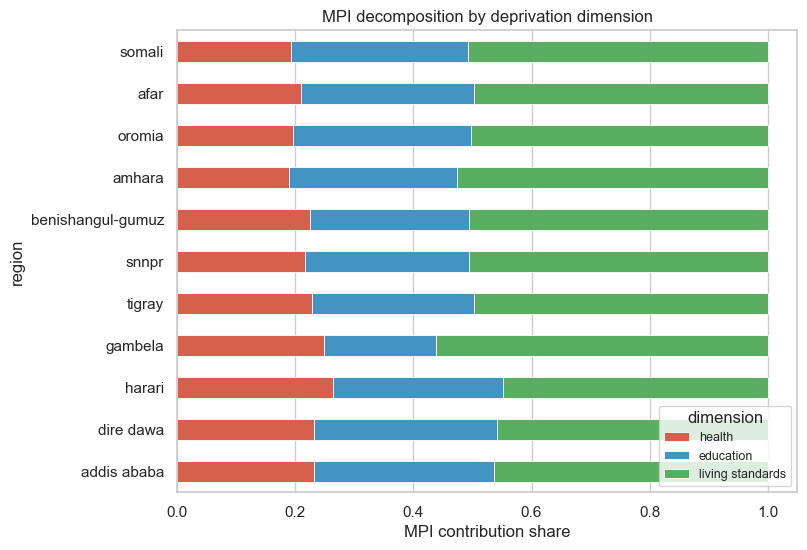

In [9]:
import matplotlib.pyplot as plt

region_labels = region_crosswalk().assign(domain=lambda d: d["dhs_code"].astype(str)
    ).set_index("domain")["dhs_region"]

fig, ax = plt.subplots(figsize=(8, 6))
viz.decomposition_bars(contrib, value="contribution",
                       region_labels=region_labels, ax=ax,
                       title="MPI decomposition by deprivation dimension")
viz.save_figure(fig, "decomposition_by_region_dimension")
plt.show()


## ML feature-importance overlay (descriptive)

The MPI tells us *which* households are poor and which deprivations contribute most. The ML overlay asks a different question: **conditional on a set of household characteristics that excludes the OPHI indicators themselves, which characteristics most associate with multidimensional poverty?** This is *descriptive feature importance*, not causal inference and not a targeting tool.

### Decision 4 — ML feature selection

**Problem.** The classifier predicts MPI status (`poor`) from household features. The non-negotiable constraint from CLAUDE.md: the 10 OPHI indicators themselves cannot be in the feature matrix, or the model trivially memorises the target (each OPHI indicator is a component of the target by construction). That leaves a wide menu of DHS variables — demographics, geography, infrastructure-adjacent items, wealth index. The hard question is the **DHS wealth index** (`hv270` quintile, `hv271` continuous factor score). DHS constructs it from many of the same asset / housing items that feed the OPHI living-standards indicators. Including it gives the classifier a strong predictor but a partially circular one; excluding it forces the model to find non-asset signal (demographics, region, schooling).

**Diagnostic.** What is the candidate feature set, and how correlated is the DHS wealth index with the OPHI living-standards indicators it shares items with?

In [10]:
# Use available-case scoring so we don't lose 'poor' labels for the ML overlay
hh_ac = mpi.build_household_mpi(hr, pr, br, missing_policy="available-case")
X, y, groups, weights = ml.build_feature_matrix(hr, pr, hh_ac)
print(f"X.shape = {X.shape}")
print(f"y NaN = {int(y.isna().sum())} / {len(y)}; "
      f"clusters in groups = {groups.nunique()}")

# How close is the DHS wealth quintile to the OPHI living-standards score?
ls = mpi.DIMENSIONS["living_standards"]
ls_dep_count = hh_ac.set_index(["hv001", "hv002"])[ls].sum(axis=1)
quintile = hr.set_index(["hv001", "hv002"])["hv270"]
joined = pd.concat([ls_dep_count.rename("ls_dep"), quintile], axis=1).dropna()
corr = joined["ls_dep"].corr(joined["hv270"], method="spearman")
print(f"Spearman(LS deprivation count, wealth quintile) = {corr:+.3f}")

# Loud assertion: no OPHI indicator made it into the feature matrix
assert not ml.EXCLUDED.intersection(X.columns), "OPHI leakage"
print("OK — no OPHI indicators leaked into X.columns")


X.shape = (8663, 23)
y NaN = 0 / 8663; clusters in groups = 305
Spearman(LS deprivation count, wealth quintile) = -0.818
OK — no OPHI indicators leaked into X.columns


**Options considered.**

1. **Include the DHS wealth index, document the circularity caveat (chosen).** Wealth index will likely dominate SHAP. That is itself the finding — DHS's own composite index, built from a superset of the OPHI living-standards items, recovers most of the predictive signal. Caveat printed in the notebook and noted in the README decisions table.
2. **Exclude wealth index entirely.** Eliminates the circularity but throws away the most-used poverty proxy in the DHS literature. Forces the model onto demographics / region / schooling — interesting but the SHAP story gets thinner.
3. **Include only `hv271` (continuous factor score), drop `hv270` (quintile).** Compromise: same circularity, but cleaner numerics.

**Decision.** Option 1 — **include both `hv270` and `hv271`**, and document the circularity. The classifier's signal includes wealth-from-assets, which is what an honest descriptive feature-importance overlay should show; pruning it is the bigger lie. The README decisions table flags this. The 10 OPHI indicators themselves are *hard-excluded* by `ml.EXCLUDED`, asserted at construction time.

**Sensitivity.** Re-run the classifier with `hv270` / `hv271` dropped — see `03_robustness.ipynb` for the AUC delta and the top-10 SHAP table side-by-side. Expectation: AUC drops a few points and demographics / region rise in the ranking.


### Decision 5 — Cluster-respecting train/test split

**Problem.** DHS uses a stratified multistage cluster sample. Households in the same cluster (PSU, `hv001`) are spatially contiguous — they share local water sources, road access, market access, schools. A random train/test split puts some households from cluster X in train and others from the same cluster in test, so the model trains on the test-set environment. Test performance inflates and the feature-importance story is contaminated by spatial auto-correlation. The correct setup keeps every cluster wholly inside one fold.

**Diagnostic.** Quantify the gap: run the same model with random `KFold` vs. clustered `GroupKFold` and read off the inflation.

In [11]:
diag = ml.leakage_diagnostic(X, y, groups, model="rf", n_splits=5)
print(f"random KFold      AUC = {diag['random_mean']:.3f}")
print(f"clustered GKFold  AUC = {diag['clustered_mean']:.3f}")
print(f"gap (random - clustered) = {diag['gap']:+.3f}")
if diag['gap'] > 0.01:
    print("-> random CV is over-optimistic; clusters carry spatial signal "
          "the model would otherwise see via train-test leakage.")
elif diag['gap'] < -0.01:
    print("-> clustered CV scored higher than random here. On real DHS this "
          "can happen if cluster grouping happens to align with target signal; "
          "the rule still applies because the WORST-case contamination is what "
          "justifies it.")
else:
    print("-> the gap is small for this model/feature set, but the rule still "
          "applies because it can reopen on a different model.")


random KFold      AUC = 0.937
clustered GKFold  AUC = 0.936
gap (random - clustered) = +0.001
-> the gap is small for this model/feature set, but the rule still applies because it can reopen on a different model.


**Options considered.**

1. **Random `KFold(shuffle=True)`.** Sklearn default. Over-optimistic on spatial / clustered data — rejected.
2. **`StratifiedKFold` on the target.** Preserves class balance per fold but does nothing about cluster contamination — rejected for the same reason.
3. **`GroupKFold(groups=hv001)` (chosen).** Each cluster is wholly inside one fold; no household leaks across the train/test boundary.
4. **Spatial leave-one-region-out.** Stronger but loses degrees of freedom on only ~11 regions. Useful as a robustness check, not the headline split.

**Decision.** Option 3 — **`GroupKFold` grouped on `hv001`**, 5 folds. The leakage diagnostic is also reported so the reader sees the gap rather than just being told to trust the rule.

**Sensitivity.** The robustness notebook reports leave-one-region-out performance as a stress test, and varies `n_splits` (3 / 5 / 10) to confirm the AUC point estimate isn't driven by the fold count.


In [12]:
cv = ml.cross_validate_clustered(X, y, groups, model="xgb", n_splits=5)
print(f"XGB (GroupKFold on hv001, 5 folds):")
print(f"  AUC = {cv['auc_mean']:.3f} +/- {cv['auc_std']:.3f}")
print(f"  F1  = {cv['f1_mean']:.3f} +/- {cv['f1_std']:.3f}")
print(f"  n trained = {cv['n_train']:,}")


XGB (GroupKFold on hv001, 5 folds):
  AUC = 0.934 +/- 0.016
  F1  = 0.898 +/- 0.017
  n trained = 8,663


### Decision 6 — SHAP aggregation with sampling weights

**Problem.** SHAP gives a per-row, per-feature contribution. To summarise feature importance across the test set, the standard move is the mean of the absolute SHAP value per feature. On a survey sample, the unweighted mean is **not** a nationally representative summary — households are sampled with unequal probability (urban over-sampled, sparse strata over-sampled), and the weighted vs unweighted means can differ materially. If the SHAP narrative is "in Ethiopia, feature X drives MPI status the most," the aggregation needs the DHS weights.

**Diagnostic.** Compute both, side-by-side, and inspect the ratio.

In [13]:
sm = ml.shap_summary(cv["model"], X, sample_weight=weights, top_n=15)
sm["ratio_w_to_uw"] = sm["weighted_mean_abs_shap"] / sm["mean_abs_shap"]
display(sm.round(4))

# Rank correlation between weighted and unweighted matters more than the
# absolute values — close to 1 -> weighting is a small correction; closer to 0
# -> weighting changes the story and the headline must use it.
from scipy.stats import spearmanr
rho, _ = spearmanr(sm["mean_abs_shap"], sm["weighted_mean_abs_shap"])
print(f"Spearman(weighted, unweighted top-15) = {rho:+.3f}")


,feature,mean_abs_shap,weighted_mean_abs_shap,rank,ratio_w_to_uw
0,hv271,1.9249,1.5487,1,0.8046
1,mean_schooling_adults,1.5960,1.5443,2,0.9676
2,max_age,0.4594,0.4663,3,1.0152
3,share_female,0.3013,0.2668,4,0.8856
4,hv040,0.2630,0.2620,5,0.9959
5,mean_age,0.2619,0.2584,6,0.9867
6,share_child,0.2341,0.2168,7,0.9262
7,hv009,0.1717,0.1816,8,1.0578
8,region_4,0.0862,0.1715,9,1.9903
9,hv270,0.1423,0.1206,10,0.8477


Spearman(weighted, unweighted top-15) = +0.968


**Options considered.**

1. **Unweighted mean |SHAP|.** Defensible if the claim is "in this sample, feature X drives prediction." Misleading if the claim is "in Ethiopia." On DHS the over-sampled strata are not nationally representative without weights.
2. **Weighted mean |SHAP| (chosen for national claims).** Use `hv005 / 1e6` as the per-row weight. The hero figure and the README headline both rest on nationally representative claims, so the weighted aggregation is the right default.
3. **Both, side-by-side.** Report weighted as the headline, keep the unweighted as the within-sample comparator. This is what the notebook actually does — `ml.shap_summary` returns both columns and the visual foregrounds the weighted one.

**Decision.** Option 3, with the **weighted** column as the headline. The top-15 SHAP table sorts by `weighted_mean_abs_shap`; the unweighted column stays visible so the reader can see how much the weighting moved the ranking. The full (uncapped) SHAP summary plot is in `03_robustness.ipynb`, using the same weighting.

**Sensitivity.** Robustness notebook adds (a) rank correlation between weighted and unweighted top-15 and (b) a weighted bootstrap CI band around the top-15 mean |SHAP| values.


## Hero figure

Single figure conveying the main finding: the regional MPI choropleth (sequential `YlOrRd`) plus an overlay marker at each region's centroid keyed to the **dominant deprivation dimension** for that region (health = red circle, education = blue triangle, living standards = green square).

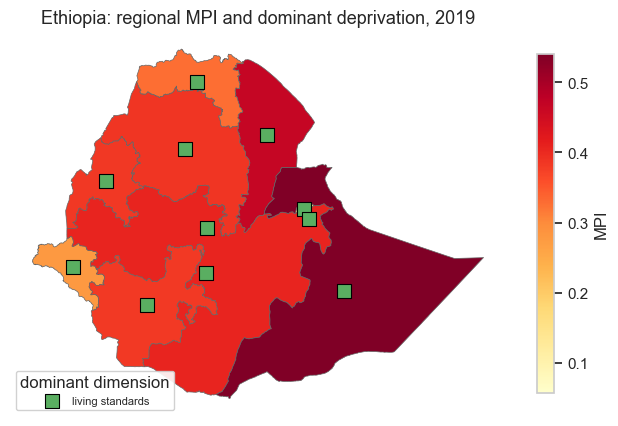

In [14]:
gadm = load_gadm_admin1()
xw = region_crosswalk()

overlay = mpi.dominant_deprivation(hh, by="hv024", level="dimension")

fig, ax = viz.hero_choropleth(reg, overlay, gadm=gadm, crosswalk=xw)
viz.save_figure(fig, "hero")
plt.show()


## Findings

We instantiate the headline numbers programmatically so they stay in sync if the data is rebuilt.

In [15]:
nat_row = nat.iloc[0]
top_region = reg_named.sort_values("MPI", ascending=False).iloc[0]
bot_region = reg_named.sort_values("MPI", ascending=False).iloc[-1]
top_dim = (contrib.groupby("dimension")["weighted_h"].sum()
           .sort_values(ascending=False))
n_regions = reg_named["domain"].nunique()
top_feat = sm.iloc[0]

print(f"- National MPI = {nat_row['MPI']:.3f} "
      f"(95% CI [{nat_row['MPI_lci']:.3f}, {nat_row['MPI_uci']:.3f}]); "
      f"H = {nat_row['H']:.1%}, A = {nat_row['A']:.3f}.")
print(f"- Highest-MPI region: {top_region['dhs_region']} "
      f"(MPI = {top_region['MPI']:.3f}); "
      f"lowest: {bot_region['dhs_region']} (MPI = {bot_region['MPI']:.3f}).")
print(f"- Across {n_regions} regions, the deprivation dimension contributing "
      f"most to MPI (national, weighted) is "
      f"'{top_dim.index[0]}' "
      f"(share = {top_dim.iloc[0] / top_dim.sum():.1%}).")
print(f"- ML overlay top feature (weighted mean |SHAP|): "
      f"{top_feat['feature']} "
      f"({top_feat['weighted_mean_abs_shap']:.4f}).")
print(f"- Random vs. clustered CV gap = {diag['gap']:+.3f} AUC — "
      f"empirical justification for GroupKFold on hv001.")


- National MPI = 0.385 (95% CI [0.362, 0.408]); H = 70.9%, A = 0.544.
- Highest-MPI region: somali (MPI = 0.540); lowest: addis ababa (MPI = 0.056).
- Across 11 regions, the deprivation dimension contributing most to MPI (national, weighted) is 'living_standards' (share = 50.4%).
- ML overlay top feature (weighted mean |SHAP|): hv271 (1.5487).
- Random vs. clustered CV gap = +0.001 AUC — empirical justification for GroupKFold on hv001.


## Limitations

- **One wave (2019), no time trend.** DHS Ethiopia is roughly five-yearly; this is a static snapshot and pre-dates several recent shocks (conflict, drought). Findings should be read in that frame.
- **OPHI methodology choices are inherited.** The 10 indicators, the three equally-weighted dimensions, and the k = 1/3 cutoff are OPHI conventions, not data-driven choices. We adopt them deliberately for cross-country comparability, but they encode value judgements (e.g. equal weighting across dimensions).
- **Child mortality from BR uses the classic OPHI "any child has died" rule (`b5 == 0`)**, not the revised 5-year-window / under-18 restriction. Documented as Decision #3 in the implementation plan.
- **ML is descriptive feature importance, not causal.** SHAP attributions tell us which features the classifier uses to discriminate poor from non-poor — they are not effect sizes and do not licence "feature X causes poverty" claims.
- **Wealth-index circularity.** `hv270` / `hv271` are constructed from many of the same asset/housing items that feed the OPHI living-standards indicators, so the SHAP table partially "rediscovers the wealth index". This is documented (Decision #7) and a wealth-dropped sensitivity lives in `03_robustness.ipynb`.
- **No targeting.** This project is not a poverty-targeting program. Operationalising any of these estimates into a targeting tool requires program design, harms analysis, and ethics review — explicitly out of scope.


## Decisions summary

| # | Decision | Chose | Why (anchored in diagnostic) | Sensitivity |
|---|---|---|---|---|
| 1 | Missing OPHI items | Drop incomplete households | OPHI standard (cross-country comparability) despite ~36% loss (nutrition-driven, 24–50% by region) | Available-case in `03_robustness.ipynb` — load-bearing given the drop size; check is whether regional ranking holds |
| 2 | Poverty cutoff k | k = 1/3 | OPHI Global MPI default; required for cross-country comparability | k ∈ {0.20, 0.50} panel in `03_robustness.ipynb` |
| 3 | Survey design | `svy` 0.18.1 (strata + PSU + weights) | `samplics` archived; `svy` is the maintained successor with Taylor variance; naive SE was substantially understated | N/A (correctness requirement) |
| 4 | ML features | Include DHS wealth index, hard-exclude the 10 OPHI indicators | Honest descriptive overlay should reflect the wealth-from-assets signal; OPHI leakage enforced by assertion in `ml.build_feature_matrix` | Wealth-dropped re-run + AUC delta in `03_robustness.ipynb` |
| 5 | Train/test split | `GroupKFold(groups=hv001)`, 5 folds | Random vs clustered AUC gap quantified above — empirical justification for the rule | Leave-one-region-out + `n_splits ∈ {3, 5, 10}` in `03_robustness.ipynb` |
| 6 | SHAP aggregation | Weighted by DHS sampling weight | National claims require survey-weighted aggregation; unweighted column retained for comparator | Spearman(weighted, unweighted) + weighted bootstrap CIs in `03_robustness.ipynb` |


## Reproducibility

- **Environment:** conda env `portfolio`, Python 3.14.
- **Install:** `pip install -e ".[viz,survey,ml]"` from the repo root.
- **Raw data:** DHS Ethiopia 2019 recodes in `data/raw/ET<rec>81DT/ET<rec>81FL.DTA` (HR, PR, BR required; KR/IR present but unused by the MPI engine). The license forbids redistribution, so raw files are gitignored — see `data/raw/README.md` for the registered-access workflow.
- **GADM 4.1 Ethiopia GeoPackage** is downloaded on first use into `data/external/` (cached HTTP).
- **Run:** open `notebooks/02_main.ipynb`, "Kernel → Restart & Run All". Runtime is dominated by the XGBoost CV (~tens of seconds at most for ~8.6k households).

Below we write a PII-free analytic export to `data/processed/` so downstream notebooks (e.g. `03_robustness.ipynb`) can reuse it without re-running the indicator construction.

In [16]:
from ethiopia_mpi.data import write_processed

export_cols = (
    ["hv001", "hv002", "hv005", "hv021", "hv022", "hv023", "hv024", "hv025"]
    + list(mpi.INDICATORS)
    + ["score", "n_missing_ind", "poor", "censored_score"]
)
export = hh[export_cols].copy()
# Cast survey-design IDs to nullable ints for parquet compactness
for c in ("hv001", "hv002", "hv021", "hv022", "hv023", "hv024", "hv025"):
    export[c] = export[c].astype("Int64")
path = write_processed(export, "households_mpi")
print(f"Wrote {len(export):,} rows -> {path.relative_to(path.parents[2])}")
print("Columns:", list(export.columns))


Wrote 8,663 rows -> data\processed\households_mpi.parquet
Columns: ['hv001', 'hv002', 'hv005', 'hv021', 'hv022', 'hv023', 'hv024', 'hv025', 'nutrition', 'child_mortality', 'years_schooling', 'school_attendance', 'cooking_fuel', 'sanitation', 'drinking_water', 'electricity', 'housing', 'assets', 'score', 'n_missing_ind', 'poor', 'censored_score']
